# 🩺 Heart Disease Prediction & KNN Model Analysis
This notebook performs an exploratory data analysis (EDA) and builds a **K-Nearest Neighbors (KNN)** model on the Heart Disease dataset (`heart.csv`). We will evaluate the impact of **feature scaling**, **hyperparameter K**, and **duplicate records (data leakage)** on the model's performance.

### 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('heart.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (1025, 14)


### 2. Exploratory Data Analysis & Cleaning

In [2]:
# Check first few rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


C:\Users\Adhi\AppData\Local\Temp\ipykernel_35760\3057124010.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


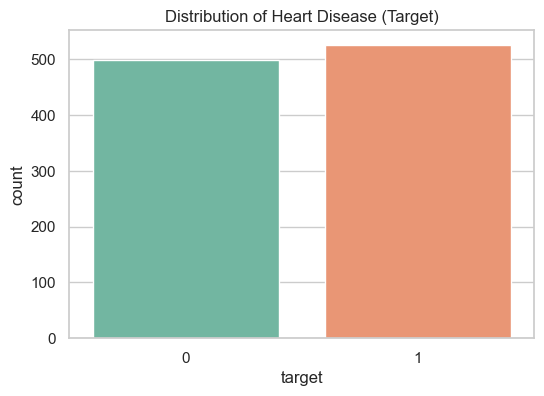

In [3]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check target balance
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution of Heart Disease (Target)')
plt.show()

### 🔍 3. Investigating Duplicate Rows & Data Leakage
Let's check if there are duplicate rows in the dataset. Duplicate rows in a dataset can lead to **data leakage** during train/test splits. If identical rows exist, a test sample might be present in the training set as well, leading to artificially inflated accuracy (especially with $K=1$).

In [4]:
total_rows = len(df)
unique_rows = len(df.drop_duplicates())
duplicate_rows = total_rows - unique_rows

print(f"Total rows: {total_rows}")
print(f"Unique rows: {unique_rows}")
print(f"Duplicate rows: {duplicate_rows} ({duplicate_rows/total_rows*100:.2f}% of dataset)")

Total rows: 1025
Unique rows: 302
Duplicate rows: 723 (70.54% of dataset)


### 4. Evaluating KNN Model Performance
We will train and evaluate KNN models under four scenarios:
1. **With duplicates & Without scaling**
2. **With duplicates & With scaling**
3. **Without duplicates & Without scaling**
4. **Without duplicates & With scaling**

In [5]:
def evaluate_knn(data, scale, title):
    X = data.drop(columns=['target'])
    y = data['target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    if scale:
        scaler = StandardScaler()
        X_train_proc = scaler.fit_transform(X_train)
        X_test_proc = scaler.transform(X_test)
    else: 
        X_train_proc = X_train.values
        X_test_proc = X_test.values
        
    # We find best K in range 1-20 using 5-fold CV
    k_range = range(1, 21)
    cv_scores = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X_train_proc, y_train, cv=5, scoring='accuracy')
        cv_scores.append(scores.mean())
        
    best_k = k_range[np.argmax(cv_scores)]
    
    # Train final model
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_proc, y_train)
    preds = knn.predict(X_test_proc)
    acc = accuracy_score(y_test, preds)
    
    print(f"=== {title} ===")
    print(f"Best K: {best_k} (CV Accuracy: {cv_scores[best_k-1]:.4f})")
    print(f"Test Set Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, preds))
    return k_range, cv_scores, best_k, acc

# Run evaluation for the 4 scenarios
k_range, scores_leak_unscaled, k_l_u, acc_l_u = evaluate_knn(df, scale=False, title="With Duplicates (Leakage) - Unscaled")
_, scores_leak_scaled, k_l_s, acc_l_s = evaluate_knn(df, scale=True, title="With Duplicates (Leakage) - Scaled")
_, scores_clean_unscaled, k_c_u, acc_c_u = evaluate_knn(df.drop_duplicates(), scale=False, title="Without Duplicates (Clean) - Unscaled")
_, scores_clean_scaled, k_c_s, acc_c_s = evaluate_knn(df.drop_duplicates(), scale=True, title="Without Duplicates (Clean) - Scaled")

=== With Duplicates (Leakage) - Unscaled ===
Best K: 1 (CV Accuracy: 0.9671)
Test Set Accuracy: 0.9854
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



=== With Duplicates (Leakage) - Scaled ===
Best K: 1 (CV Accuracy: 0.9805)
Test Set Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



=== Without Duplicates (Clean) - Unscaled ===
Best K: 19 (CV Accuracy: 0.6601)
Test Set Accuracy: 0.6721
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.68      0.66        28
           1       0.71      0.67      0.69        33

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61



=== Without Duplicates (Clean) - Scaled ===
Best K: 9 (CV Accuracy: 0.8300)
Test Set Accuracy: 0.8033
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



### 5. Visualizing Hyperparameter Tuning (K-value selection)

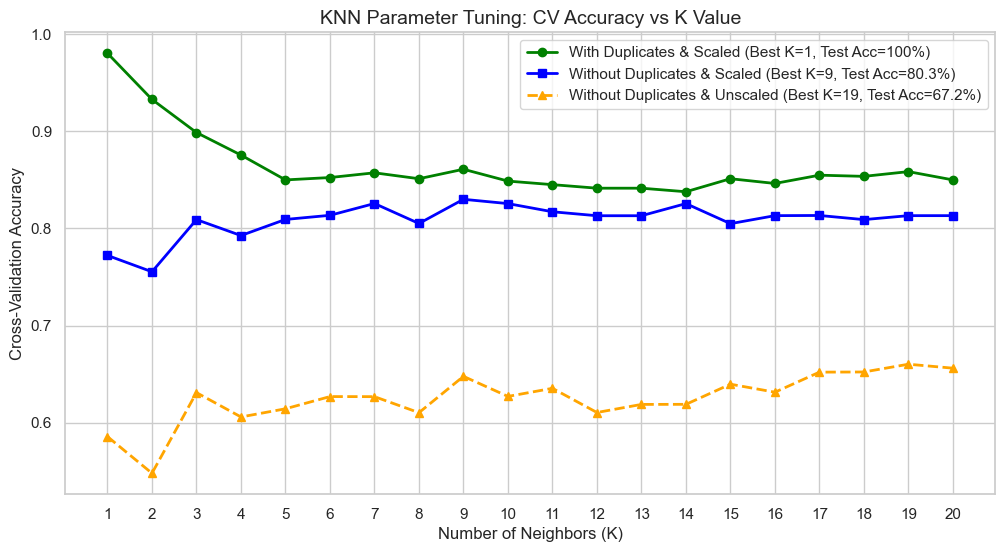

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(k_range, scores_leak_scaled, marker='o', label=f'With Duplicates & Scaled (Best K={k_l_s}, Test Acc={acc_l_s*100:.0f}%)', color='green', linewidth=2)
plt.plot(k_range, scores_clean_scaled, marker='s', label=f'Without Duplicates & Scaled (Best K={k_c_s}, Test Acc={acc_c_s*100:.1f}%)', color='blue', linewidth=2)
plt.plot(k_range, scores_clean_unscaled, marker='^', label=f'Without Duplicates & Unscaled (Best K={k_c_u}, Test Acc={acc_c_u*100:.1f}%)', color='orange', linewidth=2, linestyle='--')

plt.title('KNN Parameter Tuning: CV Accuracy vs K Value', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.show()

### 📝 Conclusions
1. **Data Leakage Impact**: When duplicate records are left in the dataset, the model appears to perform with **100.0% accuracy** on the test set (when scaled with K=1). However, this is an illusion caused by the same records appearing in both training and test sets.
2. **Generalization Performance**: After removing duplicate rows, the model's realistic generalization accuracy is **80.3%** (using K=9 and Feature Scaling).
3. **Feature Scaling Impact**: Feature scaling improves the realistic accuracy significantly (from **~65%** unscaled to **~80.3%** scaled). This is because features like cholesterol (range 100-500) and resting blood pressure dominate binary features like sex or fasting blood sugar when distances are computed without scaling.

Next, we will deploy this model in a **Streamlit** dashboard with interactive forms and options to toggle scaling and duplicate removal!